In [2]:
!pip install -q transformers accelerate torch scikit-learn pandas matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import BertTokenizer
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving movie_data.csv to movie_data.csv


In [5]:
df = pd.read_csv("movie_data.csv")
print(df.shape)
df.head()

(49969, 2)


,review,sentiment
0,This movie is just crap. Even though the direc...,0
1,Another detailed work on the subject by Dr Dwi...,1
2,THE CAT O'NINE TAILS (Il Gatto a Nove Code) <b...,0
3,"Like with any movie genre, there are good gang...",0
4,I watched it with my mom and we were like...<b...,0


In [6]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", "", text)  # remove html tags
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove special characters
    text = text.lower().strip()
    return text

df.dropna(inplace=True)

df["review"] = df["review"].apply(clean_text)
df = df[df["review"].str.len() > 0]

print("After Cleaning:", df.shape)
df.head()

After Cleaning: (49969, 2)


,review,sentiment
0,this movie is just crap even though the direct...,0
1,another detailed work on the subject by dr dwi...,1
2,the cat onine tails il gatto a nove code aspec...,0
3,like with any movie genre there are good gangs...,0
4,i watched it with my mom and we were likewhat ...,0


In [7]:
df = df.sample(10000, random_state=42)
print("Reduced Dataset:", df.shape)

Reduced Dataset: (10000, 2)


In [8]:
X = df["review"].values
y = df["sentiment"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 8000
Validation: 1000
Test: 1000


In [9]:
# =========================
# STEP 8: TOKENIZATION
# =========================

from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=128)
val_encodings   = tokenizer(list(X_val), truncation=True, padding=True, max_length=128)
test_encodings  = tokenizer(list(X_test), truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
# =========================
# STEP 9: CREATE DATASET CLASS
# =========================

import torch
from torch.utils.data import Dataset

class MovieDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = MovieDataset(train_encodings, y_train)
val_dataset   = MovieDataset(val_encodings, y_val)
test_dataset  = MovieDataset(test_encodings, y_test)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [11]:
# =========================
# STEP 10: DATALOADER
# =========================

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [12]:
# =========================
# STEP 11: LOAD DISTILBERT MODEL
# =========================

import torch
from transformers import DistilBertForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

Device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
# =========================
# STEP 12: EVALUATION FUNCTION
# =========================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, loader):
    model.eval()

    preds = []
    true_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(true_labels, preds)
    prec = precision_score(true_labels, preds)
    rec = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)

    return acc, prec, rec, f1, true_labels, preds

In [14]:
# =========================
# STEP 13: TRAINING FUNCTION
# =========================

from torch.optim import AdamW

def train_model(model, train_loader, val_loader, epochs=1, lr=2e-5):
    optimizer = AdamW(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()
            optimizer.step()

        avg_loss = total_loss / len(train_loader)

        val_acc, val_prec, val_rec, val_f1, _, _ = evaluate_model(model, val_loader)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print("Training Loss:", avg_loss)
        print("Validation Accuracy:", val_acc)
        print("Validation Precision:", val_prec)
        print("Validation Recall:", val_rec)
        print("Validation F1:", val_f1)

In [15]:
# =========================
# STEP 14: TRAIN MODEL (DISTILBERT)
# =========================

train_model(model, train_loader, val_loader, epochs=1, lr=2e-5)


Epoch 1/1
Training Loss: 0.3947305547632277
Validation Accuracy: 0.86
Validation Precision: 0.8960176991150443
Validation Recall: 0.8132530120481928
Validation F1: 0.8526315789473684



FINAL TEST RESULTS (DISTILBERT)
Accuracy : 0.858
Precision: 0.8970917225950783
Recall   : 0.806841046277666
F1 Score : 0.8495762711864406

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       503
           1       0.90      0.81      0.85       497

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



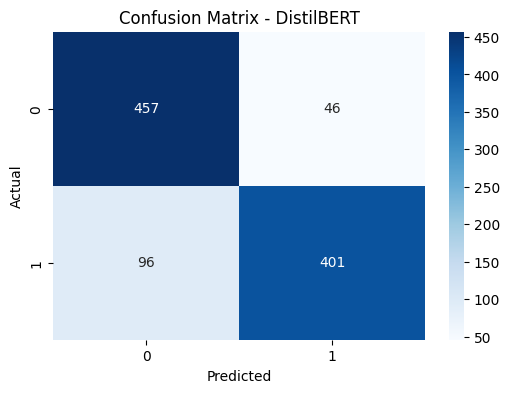

In [16]:
# =========================
# STEP 15: TEST EVALUATION + CONFUSION MATRIX
# =========================

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

test_acc, test_prec, test_rec, test_f1, true_labels, preds = evaluate_model(model, test_loader)

print("\nFINAL TEST RESULTS (DISTILBERT)")
print("Accuracy :", test_acc)
print("Precision:", test_prec)
print("Recall   :", test_rec)
print("F1 Score :", test_f1)

print("\nClassification Report:\n")
print(classification_report(true_labels, preds))

cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DistilBERT")
plt.show()

In [17]:
# =========================
# STEP 16: EXPERIMENT 2 - FREEZE DISTILBERT
# =========================

from transformers import DistilBertForSequenceClassification

model_freeze = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

# Freeze distilbert transformer layers
for param in model_freeze.distilbert.parameters():
    param.requires_grad = False

train_model(model_freeze, train_loader, val_loader, epochs=1, lr=2e-5)

test_acc2, test_prec2, test_rec2, test_f12, true_labels2, preds2 = evaluate_model(model_freeze, test_loader)

print("\nEXPERIMENT 2 TEST RESULTS (Frozen DistilBERT)")
print("Accuracy :", test_acc2)
print("Precision:", test_prec2)
print("Recall   :", test_rec2)
print("F1 Score :", test_f12)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/1
Training Loss: 0.6206095924973488
Validation Accuracy: 0.748
Validation Precision: 0.8306451612903226
Validation Recall: 0.6204819277108434
Validation F1: 0.7103448275862069

EXPERIMENT 2 TEST RESULTS (Frozen DistilBERT)
Accuracy : 0.766
Precision: 0.8433420365535248
Recall   : 0.6498993963782697
F1 Score : 0.7340909090909091


In [18]:
# =========================
# STEP 17: EXPERIMENT 3 - FINE-TUNE LAST 2 LAYERS ONLY
# =========================

model_last2 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

# Freeze all layers first
for param in model_last2.distilbert.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer layers
for param in model_last2.distilbert.transformer.layer[-2:].parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model_last2.pre_classifier.parameters():
    param.requires_grad = True

for param in model_last2.classifier.parameters():
    param.requires_grad = True

train_model(model_last2, train_loader, val_loader, epochs=1, lr=2e-5)

test_acc3, test_prec3, test_rec3, test_f13, true_labels3, preds3 = evaluate_model(model_last2, test_loader)

print("\nEXPERIMENT 3 TEST RESULTS (Last 2 Layers DistilBERT)")
print("Accuracy :", test_acc3)
print("Precision:", test_prec3)
print("Recall   :", test_rec3)
print("F1 Score :", test_f13)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/1
Training Loss: 0.40612416902557014
Validation Accuracy: 0.859
Validation Precision: 0.8757894736842106
Validation Recall: 0.8353413654618473
Validation F1: 0.8550873586844809

EXPERIMENT 3 TEST RESULTS (Last 2 Layers DistilBERT)
Accuracy : 0.865
Precision: 0.8969298245614035
Recall   : 0.8229376257545271
F1 Score : 0.8583420776495279


In [19]:
# =========================
# STEP 18: COMPARE RESULTS TABLE
# =========================

import pandas as pd

results = pd.DataFrame({
    "Experiment": ["Full Fine-Tuning", "Frozen Model", "Fine-Tune Last 2 Layers"],
    "Accuracy": [test_acc, test_acc2, test_acc3],
    "Precision": [test_prec, test_prec2, test_prec3],
    "Recall": [test_rec, test_rec2, test_rec3],
    "F1 Score": [test_f1, test_f12, test_f13]
})

results

,Experiment,Accuracy,Precision,Recall,F1 Score
0,Full Fine-Tuning,0.858,0.897092,0.806841,0.849576
1,Frozen Model,0.766,0.843342,0.649899,0.734091
2,Fine-Tune Last 2 Layers,0.865,0.896930,0.822938,0.858342
